# Segunda actividad: encontrar un neutrino

Estos son datos **reales** de IceCube: unas 8 horas del año 2012. Entre decenas de miles de muones atmosféricos hay unos pocos neutrinos escondidos.

Tu misión: encontrarlos.

### Preparación
Ejecuta esta celda para descargar los datos y el código de la actividad.

In [1]:
# ID del archivo de datos en Google Drive (real_8hr_2012.hdf5)
FILE_ID = "1P1w1z8NKj2htu9VGaAK9Damt7ZVx76Eu"

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()
    !gdown -q {FILE_ID} -O real_8hr_2012.hdf5
    !git clone -q https://github.com/Harvard-Neutrino/CAFE-2026-actividades.git
    import sys; sys.path.insert(0, "CAFE-2026-actividades")
    H5 = "real_8hr_2012.hdf5"
else:
    import sys; sys.path.insert(0, ".")
    H5 = "data/real_8hr_2012.hdf5"

import numpy as np
import matplotlib.pyplot as plt
from neutrino_tools import load_events, event_display

events = load_events(H5)
print(f"Cargamos {len(events)} eventos.")

Cargamos 88418 eventos.


## 1. Mira algunos eventos

Cada evento es una partícula que cruzó el detector. Las burbujas son los sensores que se encendieron: tamaño = luz recibida, color = tiempo. Puedes **rotar** la visualización con el mouse.

Cambia el número `evt_idx` para explorar distintos eventos. Cambia `show_track` a `True` para ver las direcciones *reconstruidas*. Nota que, como estos eventos son datos reales, ¡no podemos saber las direcciones reales!

**[¿Qué ves? Mira por lo menos 10 eventos diferentes. Responde:]**

* ¿De dónde vienen estas partículas?
* ¿Crees en la dirección reconstruida? ¿Sí o no? ¿Por qué?

* Llena la siguiente tabla:
| Pregunta                                           | Respuesta |
| -------------------------------------------------- | --------- |
| Número de eventos que miraste                      |           |
| Número de eventos que fueron de arriba hacia abajo |           |
| Número de eventos que fueron de abajo hacia arriba |           |
| Número de eventos bien reconstruidos               |           |

In [2]:
evt_idx = 0
event_display(events[evt_idx], show_track=False) # Cámbiame: False -> True

## 2. ¿De dónde vienen?

Para ver la tendencia de **todos** los eventos a la vez, hacemos un histograma del ángulo **zenith** reconstruido:

0° = hacia abajo, 90° = horizonte, 180° = hacia arriba.

Recuerden que IceCube ve muchísimos muones atmosféricos que llegan desde arriba, y pocos neutrinos que vienen de todas las direcciones. Dado esto, ¿qué piensan que son los eventos con ángulos **zenith reconstruidos** por debajo de 90°: muones o neutrinos?

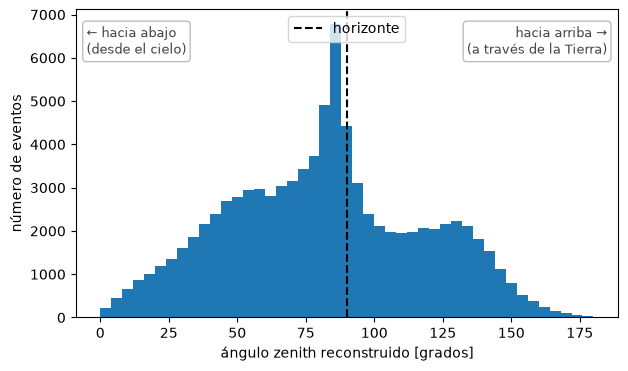

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(events.zenith_deg, bins=45)
plt.axvline(90, color="k", ls="--", label="horizonte")
plt.xlabel("ángulo zenith reconstruido [grados]")
plt.ylabel("número de eventos")
plt.legend(loc="upper center")

ax = plt.gca()
_bb = dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85)
ax.text(0.02, 0.95, "← hacia abajo\n(desde el cielo)", transform=ax.transAxes,
        va="top", ha="left", fontsize=9, color="0.25", bbox=_bb)
ax.text(0.98, 0.95, "hacia arriba →\n(a través de la Tierra)", transform=ax.transAxes,
        va="top", ha="right", fontsize=9, color="0.25", bbox=_bb)
plt.show()

## 3. Quédate con los que vienen 'hacia arriba'

Solo un neutrino puede cruzar la Tierra. Filtramos los eventos con ángulo zenith mayor a 85°.
¿Son todos neutrinos? Míralos de cerca...

* Llena la siguiente tabla:
| Pregunta                                           | Respuesta |
| -------------------------------------------------- | --------- |
| Número de eventos que miraste                      |           |
| Número de eventos bien reconstruidos               |           |

In [7]:
arriba = events[events.zenith_deg > 85]
print(f"{len(arriba)} eventos parecen venir de abajo del horizonte.")

40339 eventos parecen venir de abajo del horizonte.


In [ ]:
evt_idx = 0
event_display(arriba[evt_idx], show_track=True)

## 4. La calidad del ajuste (rlogl)

La reconstrucción reporta qué tan bien la trayectoria explica la luz observada: **rlogl** (más pequeño = mejor ajuste). Los muones mal reconstruidos tienen rlogl grande.

Hacemos un histograma 2D para investigar las propriedades de nuestros eventos. Que notas sobre la figura que resulta?
* En quales partes de la figura existen mas eventos? Que creas que son?
* En qual parte de la figura crean que estan los neutrinos reales?

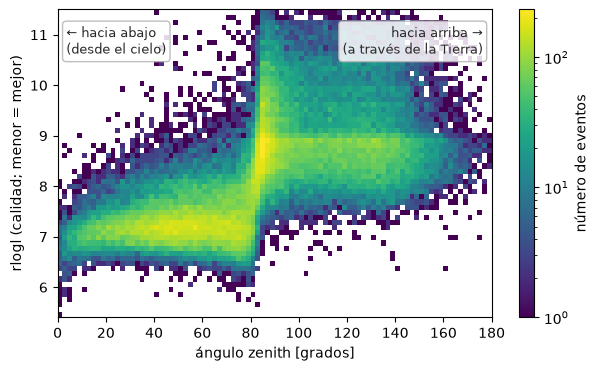

In [9]:
from matplotlib.colors import LogNorm
ok = np.isfinite(events.rlogl)   # unos pocos eventos no tienen rlogl
plt.figure(figsize=(7, 4))
plt.hist2d(events.zenith_deg[ok], events.rlogl[ok],
           bins=[90, 60], range=[[0, 180], [5.4, 11.5]],
           norm=LogNorm(), cmap="viridis")
plt.colorbar(label="número de eventos")
plt.xlabel("ángulo zenith [grados]")
plt.ylabel("rlogl (calidad; menor = mejor)")

ax = plt.gca()
_bb = dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85)
ax.text(0.02, 0.95, "← hacia abajo\n(desde el cielo)", transform=ax.transAxes,
        va="top", ha="left", fontsize=9, color="0.15", bbox=_bb)
ax.text(0.98, 0.95, "hacia arriba →\n(a través de la Tierra)", transform=ax.transAxes,
        va="top", ha="right", fontsize=9, color="0.15", bbox=_bb)
plt.show()

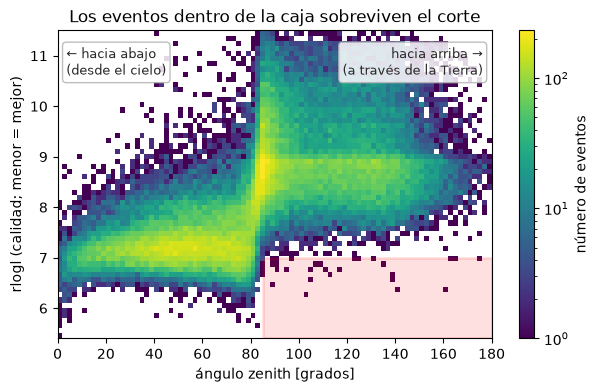

In [ ]:
# vamos a hacer un *corte* para filtrar solo los eventos con mas alta probabilidad de ser neutrinos.
# escojes los cortes abajo para mudar que eventos sobrevivan.
corte_zenith = #...    # grados: nos quedamos con los MÁS hacia arriba que esto
corte_rlogl  = #...    # calidad: nos quedamos con los MEJOR ajustados que esto (rlogl menor)


# --- dibuja el histograma 2D con tu caja de selección ---
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
ok = np.isfinite(events.rlogl)
ylo, yhi = 5.4, 11.5

plt.figure(figsize=(7, 4))
plt.hist2d(events.zenith_deg[ok], events.rlogl[ok],
           bins=[90, 60], range=[[0, 180], [ylo, yhi]],
           norm=LogNorm(), cmap="viridis")
plt.colorbar(label="número de eventos")

# la caja: los eventos adentro (zenith > corte, rlogl < corte) sobreviven
plt.gca().add_patch(Rectangle(
    (corte_zenith, ylo), 180 - corte_zenith, corte_rlogl - ylo,
    facecolor="red", alpha=0.12, edgecolor="red", lw=2))

ax = plt.gca()
_bb = dict(boxstyle="round", fc="white", ec="0.7", alpha=0.85)
ax.text(0.02, 0.95, "← hacia abajo\n(desde el cielo)", transform=ax.transAxes,
        va="top", ha="left", fontsize=9, color="0.15", bbox=_bb)
ax.text(0.98, 0.95, "hacia arriba →\n(a través de la Tierra)", transform=ax.transAxes,
        va="top", ha="right", fontsize=9, color="0.15", bbox=_bb)

plt.xlabel("ángulo zenith [grados]")
plt.ylabel("rlogl (calidad; menor = mejor)")
plt.title("Los eventos dentro de la caja sobreviven el corte")
plt.show()

## 5. Aplica los dos cortes

Aplica los cortes y investigas los eventos que resultan. Quantos eventos tienes? ¿Creas realmente que vienen hacia abajo? ¿Quales eventos creas que son realmente neutrinos? (Recuerden: estos son eventos reales! No existe modo para saber con certeza que son muones o neutrinos!)

* Escribes los indices de los eventos que creas son realmente neutrinos abajo:
    * evento ...
    * evento ...
    * evento ...

In [11]:
neutrinos = events[(events.zenith_deg > corte_zenith) & (events.rlogl < corte_rlogl)]
print(f"¡Encontraste {len(neutrinos)} candidatos a neutrino!")

¡Encontraste 27 candidatos a neutrino!


In [ ]:
evt_idx = 2
event_display(neutrinos[evt_idx])